In [28]:
import os
os.environ['HF_HOME'] = "huggingface_home_directory/"

In [29]:
import torch
torch.cuda.empty_cache()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [30]:
%pip install -q -U bitsandbytes
%pip install -q -U git+https://github.com/huggingface/transformers.git
%pip install -q -U git+https://github.com/huggingface/peft.git
%pip install -q -U git+https://github.com/huggingface/accelerate.git
%pip install -q -U datasets scipy ipywidgets matplotlib

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
beatrix-jupyterlab 2023.128.151533 requires jupyterlab~=3.6.0, but you have jupyterlab 4.2.1 which is incompatible.
spopt 0.6.0 requires shapely>=2.0.1, but you have shapely 1.8.5.post1 which is incompatible.
ydata-profiling 4.6.4 requires matplotlib<3.9,>=3.2, but you have matplotlib 3.9.0 which is incompatible.
ydata-profiling 4.6.4 requires numpy<1.26,>=1.16.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.6.4 requires scipy<1.12,>=1.4.1, but you have scipy 1.13.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [31]:
!git clone https://github.com/sachink1729/Finetuning-Mistral-7B-Chat-Doctor-Huggingface-LoRA-PEFT.git


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


fatal: destination path 'Finetuning-Mistral-7B-Chat-Doctor-Huggingface-LoRA-PEFT' already exists and is not an empty directory.


In [32]:
from datasets import load_dataset, load_from_disk

dataset = load_from_disk("/kaggle/working/Finetuning-Mistral-7B-Chat-Doctor-Huggingface-LoRA-PEFT/patients_query_sampled/")

train_dataset = dataset['train']
eval_dataset = dataset['test']

In [33]:
def formatting_func(example):
    text = f"### The following is a doctor's opinion on a person's query: \n### Patient query: {example['input']} \n### Doctor opinion: {example['output']}"
    return text

In [34]:
print(formatting_func(train_dataset[177]))


### The following is a doctor's opinion on a person's query: 
### Patient query: I have considerable lower back pain, also numbness in left buttocks and down left leg, girdling at the upper thigh.  MRI shows \"Small protrusiton of L3-4 interv. disc on left far laterally with annular fissuring fesulting in mild left neural foraminal narrowing with slight posterolateral displacement of the exiting l3 nerve root.\"  Other mild bulges L4-5 w/ fissuring, and mild buldge  L5-S1. 1) does this explain symptoms 2) I have a plane/car trip in 2 days lasting 8 hrs, then other travel.  Will this be harmful? 
### Doctor opinion: Hi, Your MRI report does explain your symptoms. Travelling is possible providing you take certain measures to make your journey as comfortable as possible. I suggest you ensure you take adequate supplies of your painkillers. When on the plane take every opportunity to move about the cabin to avoid sitting in the same position for too long. Likewise, when travelling by car, t

In [35]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM,AutoModelForSeq2SeqLM, BitsAndBytesConfig

base_model_id = "google/flan-t5-small"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id, quantization_config=bnb_config, force_download=True)

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

`low_cpu_mem_usage` was None, now set to True since model is quantized.


model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [36]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    padding_side="left",
    add_eos_token=True,
    add_bos_token=True,
)
tokenizer.pad_token = tokenizer.eos_token

def generate_and_tokenize_prompt(prompt):
    return tokenizer(formatting_func(prompt))

In [37]:
tokenized_train_dataset = train_dataset.map(generate_and_tokenize_prompt)
tokenized_val_dataset = eval_dataset.map(generate_and_tokenize_prompt)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (547 > 512). Running this sequence through the model will result in indexing errors


5000


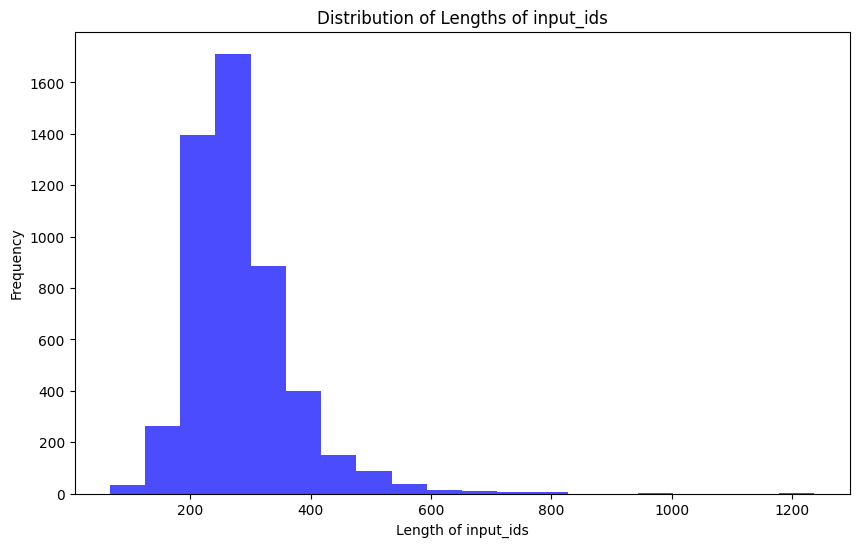

In [38]:
import matplotlib.pyplot as plt

def plot_data_lengths(tokenized_train_dataset, tokenized_val_dataset):
    lengths = [len(x['input_ids']) for x in tokenized_train_dataset]
    lengths += [len(x['input_ids']) for x in tokenized_val_dataset]
    print(len(lengths))

    # Plotting the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=20, alpha=0.7, color='blue')
    plt.xlabel('Length of input_ids')
    plt.ylabel('Frequency')
    plt.title('Distribution of Lengths of input_ids')
    plt.show()

plot_data_lengths(tokenized_train_dataset, tokenized_val_dataset)

In [39]:
max_length = 512 # This was an appropriate max length for the dataset

def generate_and_tokenize_prompt2(prompt):
    result = tokenizer(
        formatting_func(prompt),
        truncation=True,
        max_length=max_length,
        padding="max_length",
    )
    result["labels"] = result["input_ids"].copy()
    return result

In [40]:
tokenized_train_dataset = train_dataset.map(generate_and_tokenize_prompt2)
tokenized_val_dataset = eval_dataset.map(generate_and_tokenize_prompt2)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [41]:
print(tokenized_train_dataset[1]['input_ids'])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1713, 30345, 37, 826, 19, 3, 9, 2472, 31, 7, 3474, 30, 3, 9, 568, 31, 7, 11417, 10, 1713, 

5000


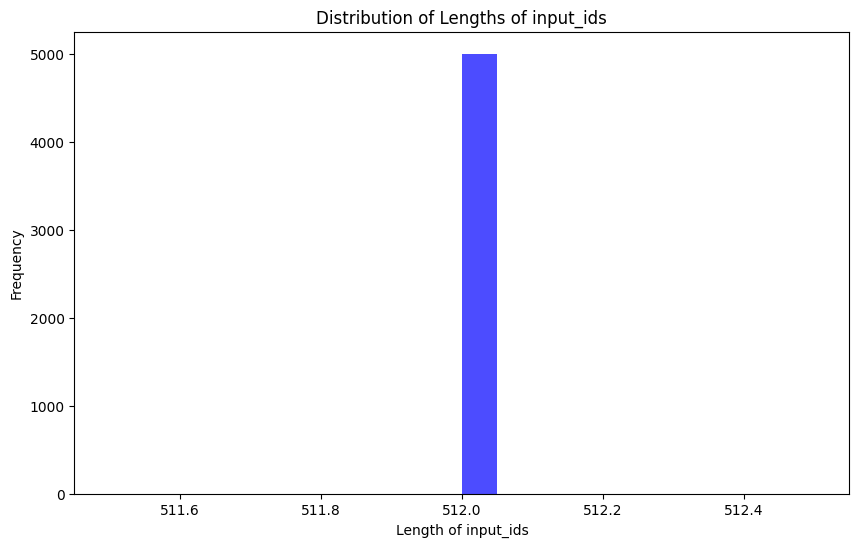

In [42]:
plot_data_lengths(tokenized_train_dataset, tokenized_val_dataset)

In [43]:
query = "Hi doc i am in the recovery after dengue, sometimes my heart feels like its rubbing with my chest and it feels very uncomfortable, what can be my problem?"
eval_prompt = """Patient's Query:\n\n {} ###\n\n""".format(query)

In [44]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    add_bos_token=True,
)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})

model_input = tokenizer(eval_prompt, return_tensors="pt").to("cuda")

model.eval()
with torch.no_grad():
    print(tokenizer.decode(model.generate(**model_input, max_new_tokens=256, repetition_penalty=1.15)[0], skip_special_tokens=True))

I am in the recovery after dengue, sometimes my heart feels like its rubbing with my chest and it feels very uncomfortable, what can be my problem?


In [45]:
from peft import prepare_model_for_kbit_training

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

In [46]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [47]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
        "lm_head",
    ],
    bias="none",
    lora_dropout=0.05,  # Conventional
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, config)
print_trainable_parameters(model)

trainable params: 522240 || all params: 59657600 || trainable%: 0.8753955908383844


In [48]:
from accelerate import FullyShardedDataParallelPlugin, Accelerator
from torch.distributed.fsdp.fully_sharded_data_parallel import FullOptimStateDictConfig, FullStateDictConfig

fsdp_plugin = FullyShardedDataParallelPlugin(
    state_dict_config=FullStateDictConfig(offload_to_cpu=True, rank0_only=False),
    optim_state_dict_config=FullOptimStateDictConfig(offload_to_cpu=True, rank0_only=False),
)

accelerator = Accelerator(fsdp_plugin=fsdp_plugin)

In [49]:
model = accelerator.prepare_model(model)

In [50]:
if torch.cuda.device_count() > 1: # If more than 1 GPU
    model.is_parallelizable = True
    model.model_parallel = True

In [51]:
import wandb
import transformers
from datetime import datetime

wandb.login(key="5927c2b895ab34cc66ecdc6d0f00d76969df1550")

project = "chat-doctor-finetune"
base_model_name = "flan-t5-small-"
run_name = base_model_name + "-" + project
output_dir = "./" + run_name

trainer = transformers.Trainer(
    model=model,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    args=transformers.TrainingArguments(
        output_dir=output_dir,
        warmup_steps=2,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=1,
        gradient_checkpointing=True,
        max_steps=500,
        learning_rate=2.5e-4, # Want a small lr for finetuning
        #bf16=True,
        optim="paged_adamw_8bit",
        logging_steps=25,              # When to start reporting loss
        logging_dir="./logs",        # Directory for storing logs
        save_strategy="steps",       # Save the model checkpoint every logging step
        save_steps=25,                # Save checkpoints every 50 steps
        evaluation_strategy="steps", # Evaluate the model every logging step
        eval_steps=25,               # Evaluate and save checkpoints every 50 steps
        do_eval=True,                # Perform evaluation at the end of training
    ),
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

model.config.use_cache = False  # silence the warnings. Please re-enable for inference!
trainer.train()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
/opt/conda/lib/python3.10/site-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs
/opt/conda/lib/python3.10/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will inste

Step,Training Loss,Validation Loss
25,4.964300,4.455608
50,4.779300,4.305034
75,4.398700,4.200159
100,5.238000,4.371899
125,4.551400,5.559434
150,4.876700,4.128150
175,4.201100,4.090430
200,4.263600,4.026190
225,4.213400,3.968768
250,4.040200,3.900841


/opt/conda/lib/python3.10/site-packages/peft/utils/save_and_load.py:197: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/opt/conda/lib/python3.10/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0

TrainOutput(global_step=500, training_loss=4.252358367919922, metrics={'train_runtime': 1107.5898, 'train_samples_per_second': 3.611, 'train_steps_per_second': 0.451, 'total_flos': 749979303936000.0, 'train_loss': 4.252358367919922, 'epoch': 0.8880994671403197})

In [53]:
import json
import matplotlib.pyplot as plt

train_checkpoints_data=json.load(open("flan-t5-small--chat-doctor-finetune/checkpoint-500/trainer_state.json"))

lr = []
loss = []
eval_loss = []
steps=[]
for x in train_checkpoints_data['log_history']:
    try:
        lr.append(x['learning_rate'])
        loss.append(x['loss'])
        steps.append(x['step'])
    except:
        eval_loss.append(x['eval_loss'])

In [54]:
lr

[0.00023845381526104418,
 0.00022590361445783133,
 0.00021335341365461845,
 0.00020080321285140563,
 0.00018825301204819278,
 0.0001757028112449799,
 0.00016315261044176708,
 0.00015060240963855423,
 0.00013805220883534135,
 0.00012550200803212853,
 0.00011295180722891567,
 0.00010040160642570282,
 8.785140562248995e-05,
 7.530120481927712e-05,
 6.275100401606426e-05,
 5.020080321285141e-05,
 3.765060240963856e-05,
 2.5100401606425704e-05,
 1.2550200803212852e-05,
 0.0]

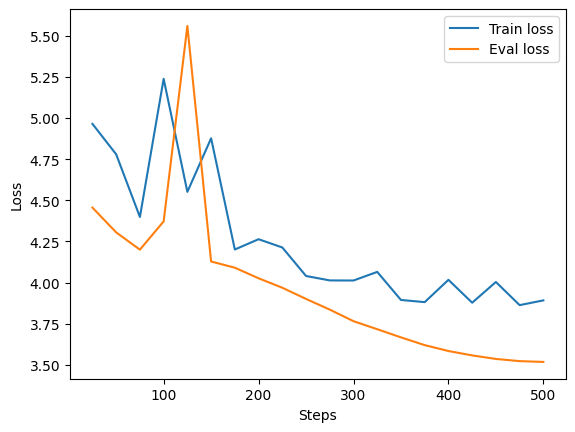

In [55]:
plt.plot(steps, loss, label="Train loss")
plt.plot(steps, eval_loss, label= "Eval loss")
leg= plt.legend()
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()